# Imports

In [1]:
import sys
import os
from pathlib import Path

In [2]:
sys.path.append(os.path.join(os.getcwd(),"..",".."))
sys.path.append(os.path.join(os.getcwd(),"..","..",".."))

In [3]:
import numpy as np
import pandas as pd

In [4]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
from backtester import BackTester

In [8]:
data_store=Path(os.getcwd()).parent.parent.parent/"Prepared_Data_Store"

# Loading Benchmark Data

In [9]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [10]:
benchmark_data=benchmark_data.sp500_returns.sort_index().tz_localize("UTC")

# BackTesting

## Trading Strategy-I

### Here we will long the stocks with higher factor values and short the stocks with lower factor values predicted by Ridge Model-14 with reg_aplha=500

In [11]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [12]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.01,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge14_factor",
    trading_strategy=trading_strategy
)

In [13]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

In [14]:
LIVE_DATE="2016-02-24"

#### Extracting Information from Zipline Results

In [15]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

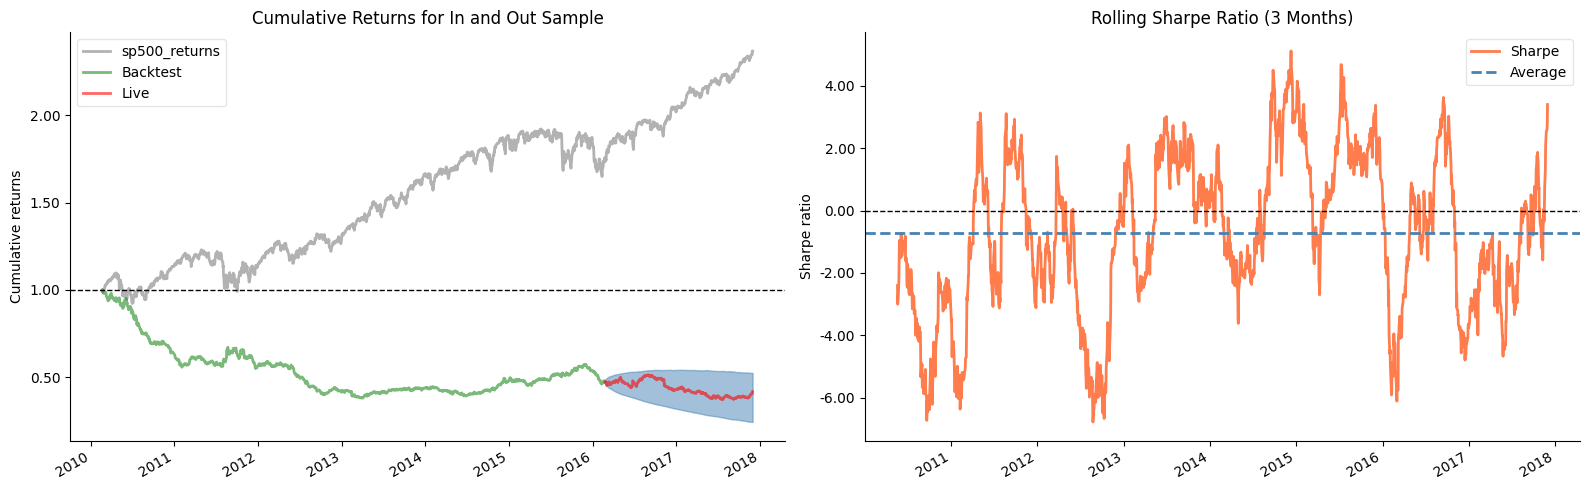

In [16]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    volatility_match=False,
    legend_loc="best",
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,62.78,2010-02-22,2017-07-18,NaT,NaN
1,NaN,NaT,NaT,NaT,NaN
2,NaN,NaT,NaT,NaT,NaN
3,NaN,NaT,NaT,NaT,NaN
4,NaN,NaT,NaT,NaT,NaN


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.39%,-3.76%,6.75%
Fukushima,0.04%,-1.22%,1.06%
EZB IR Event,-0.36%,-2.29%,1.06%
Flash Crash,-0.44%,-2.83%,1.40%
Apr14,-0.20%,-1.98%,1.76%
Oct14,0.07%,-1.65%,2.43%
Fall2015,0.10%,-1.45%,3.46%
Recovery,-0.12%,-3.99%,6.75%
New Normal,0.00%,-6.15%,5.44%


Top 10 long positions of all time,max
sid,
HSY,34.52%
APA,34.48%
DGX,34.01%
NVDA,33.72%
MOS,33.66%
DECK,30.87%
MNST,30.64%
NKE,29.88%
BIIB,29.19%


Top 10 short positions of all time,max
sid,
MDLZ,-40.71%
DGX,-38.98%
NVDA,-37.99%
WTW,-31.94%
MSCI,-31.70%
HPQ,-31.64%
AMD,-31.63%
EW,-31.32%
APA,-30.93%


Top 10 positions of all time,max
sid,
MDLZ,40.71%
DGX,38.98%
NVDA,37.99%
HSY,34.52%
APA,34.48%
MOS,33.66%
WTW,31.94%
MSCI,31.70%
HPQ,31.64%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-588614.67,$-921904.41,$333289.73
Gross profit,$13266169.87,$6489698.18,$6776471.69
Gross loss,$-13854784.54,$-7411602.58,$-6443181.96
Profit factor,$0.96,$0.88,$1.05
Avg. trade net profit,$-7.73,$-24.60,$8.61
Avg. winning trade,$354.08,$366.75,$342.73
Avg. losing trade,$-359.97,$-377.03,$-342.16
Ratio Avg. Win:Avg. Loss,$0.98,$0.97,$1.00
Largest winning trade,$15927.04,$15927.04,$15396.64
Largest losing trade,$-23581.80,$-23581.80,$-18422.25


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 13:57:16.374191177,1 days 17:03:26.498852782,1 days 10:57:00.320752279
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,267 days 00:00:00,267 days 00:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.07%,0.07%,0.07%
Avg returns losing,-0.07%,-0.07%,-0.06%
Median returns all round_trips,-0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,4.20%,4.20%,3.41%
Largest losing trade,-5.64%,-5.64%,-2.56%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.01%,-0.01%,-0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,-0.02%,-0.01%,-0.00%,0.01%,0.00%,-0.01%,0.00%,-0.01%,-0.01%,0.00%,-0.00%,0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.02%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,-0.00%,0.02%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.01%,-0.01%,0.01%,-0.00%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,-0.01%,-0.02%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,0.01%,0.00%,-0.01%,0.01%,0.00%,0.00%,0.01%,-0.01%,-0.00%,0.01%,0.00%,0.01%,0.02%,0.00%,0.00%,0.01%,-0.00%,-0.01%,0.01%,0.01%,-0.01%,0.02%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,-0.01%,0.01%,0.00%,-0.01%,-0.01%,-0.01%,-0.01%,-0.01%,0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,-0.01%,0.00%,0.01%,0.00%,0.02%,-0.00%,-0.00%,0.00%,-0.02%,0.01%,0.01%,-0.01%,-0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,-0.02%,-0.01%,-0.01%,-0.00%,-0.00%,-0.01%,-0.04%,-0.00%,-0.00%,0.01%,-0.01%,-0.03%,0.01%,0.00%,-0.01%,-0.02%,0.00%,0.00%,-0.00%,-0.00%,-0.02%,0.00%,0.01%,-0.00%,-0.01%,-0.01%,0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,0.01%,-0.01%,-0.00%,-0.01%,-0.01%,-0.01%,-0.01%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.02%,-0.00%,0.01%,0.00%,-0.01%,-0.01%,0.00%,-0.00%,0.02%,0.01%,-0.04%,-0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.02%,-0.02%,-0.01%,0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,-0.00%,-0.03%,-0.01%,0.00%,-0.04%,0.02%,0.00%,0.02%,0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.02%,0.01%,0.02%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,-0.03%,-0.01%,0.03%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,0.01%,-0.01%,0.00%,0.01%,0.01%,0.00%,-0.01%,-0.01%,0.01%,-0.01%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.02%,-0.00%,0.00%,-0.00%,-0.02%,0.01%,0.01%,-0.03%,-0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.01%,-0.01%,0.00%,-0.01%,-0.01%,-0.01%,0.01%,0.01%,-0.00%,0.01%,0.01%,0.01%,-0.00%,0.00%,-0.01%,0.

Profitability (PnL / PnL total) per name,
symbol,
MU,9.47%
RMD,7.77%
VRTX,7.30%
NVDA,6.09%
IPG,5.98%
SMCI,5.82%
RF,4.66%
STZ,4.60%
NRG,4.58%


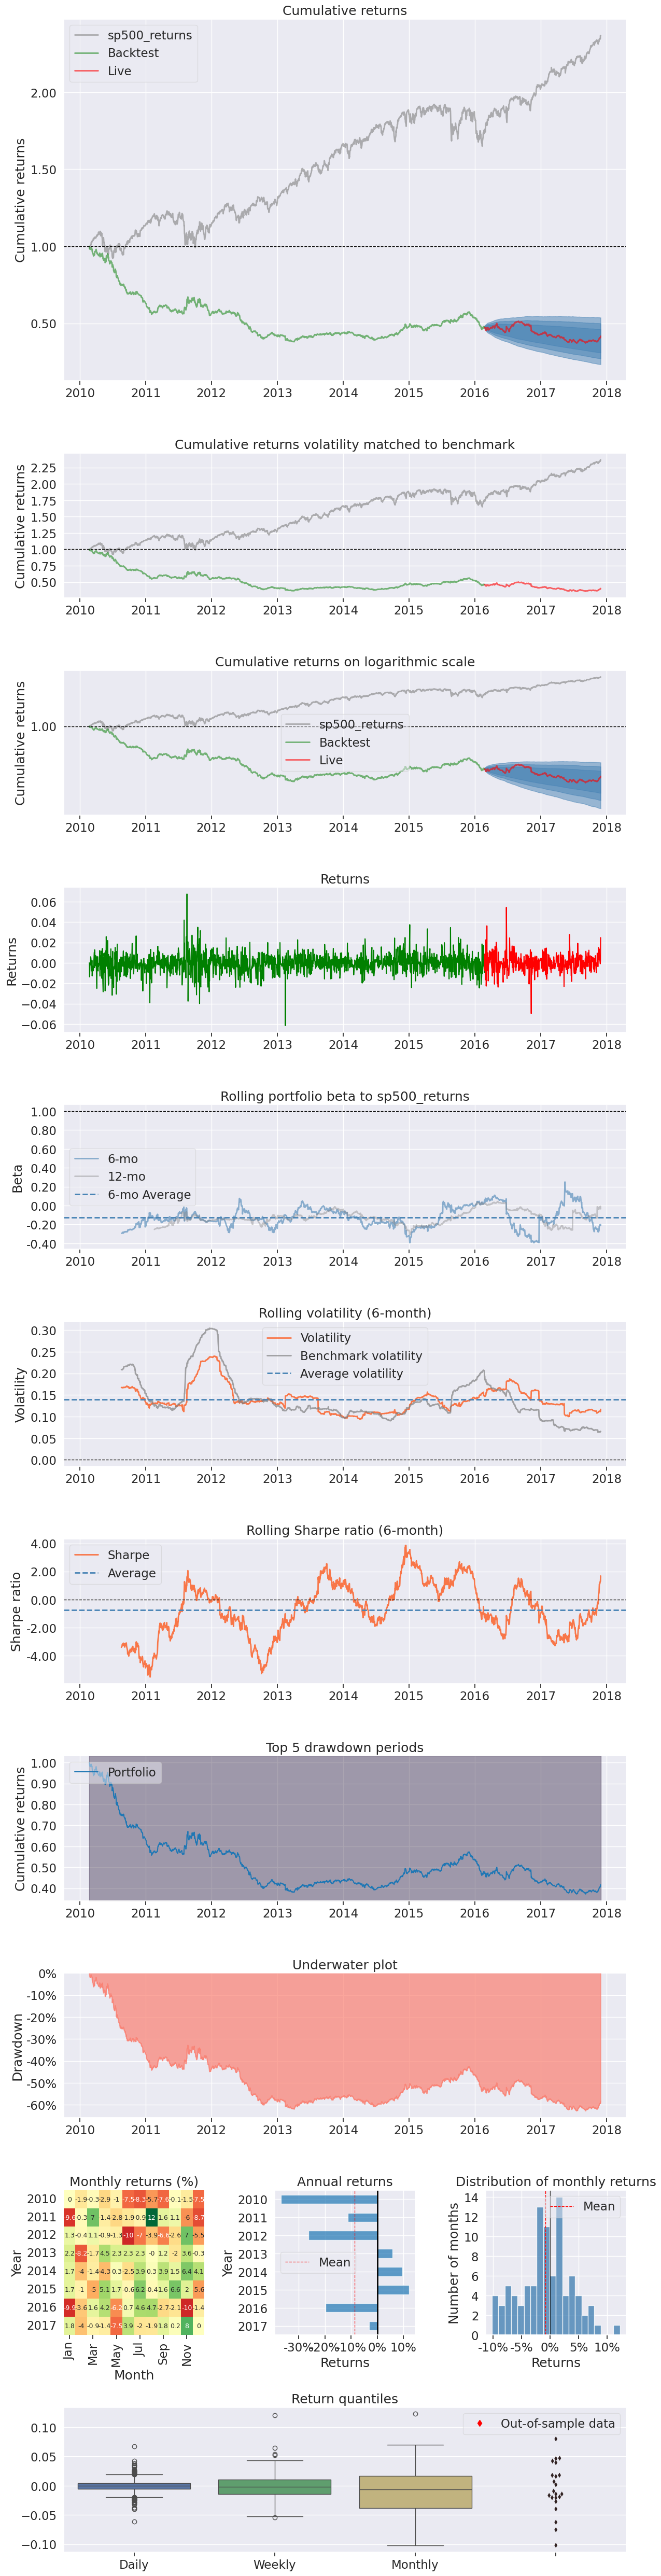

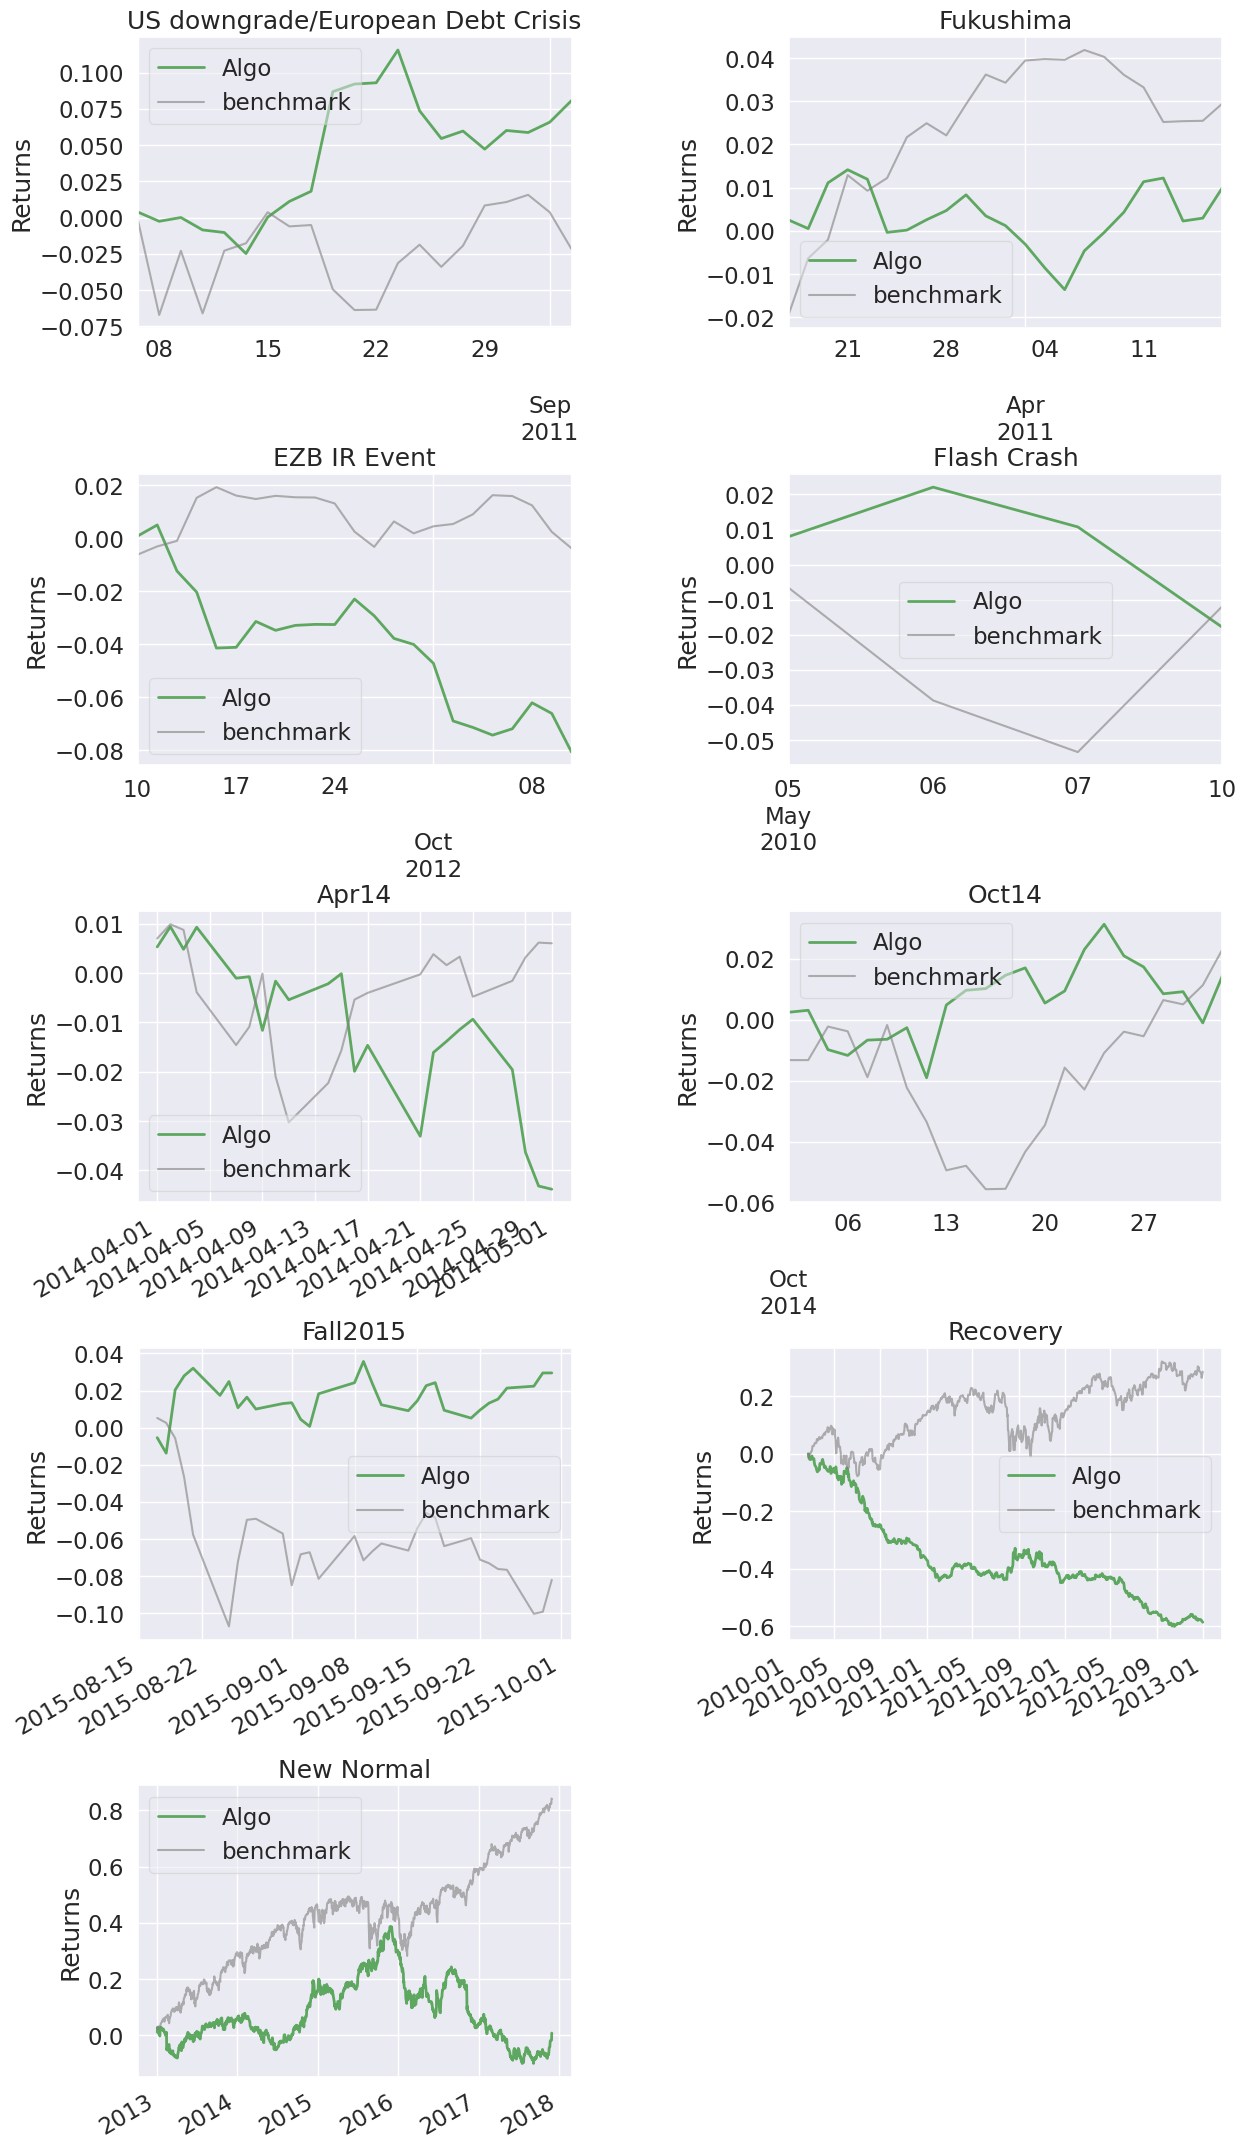

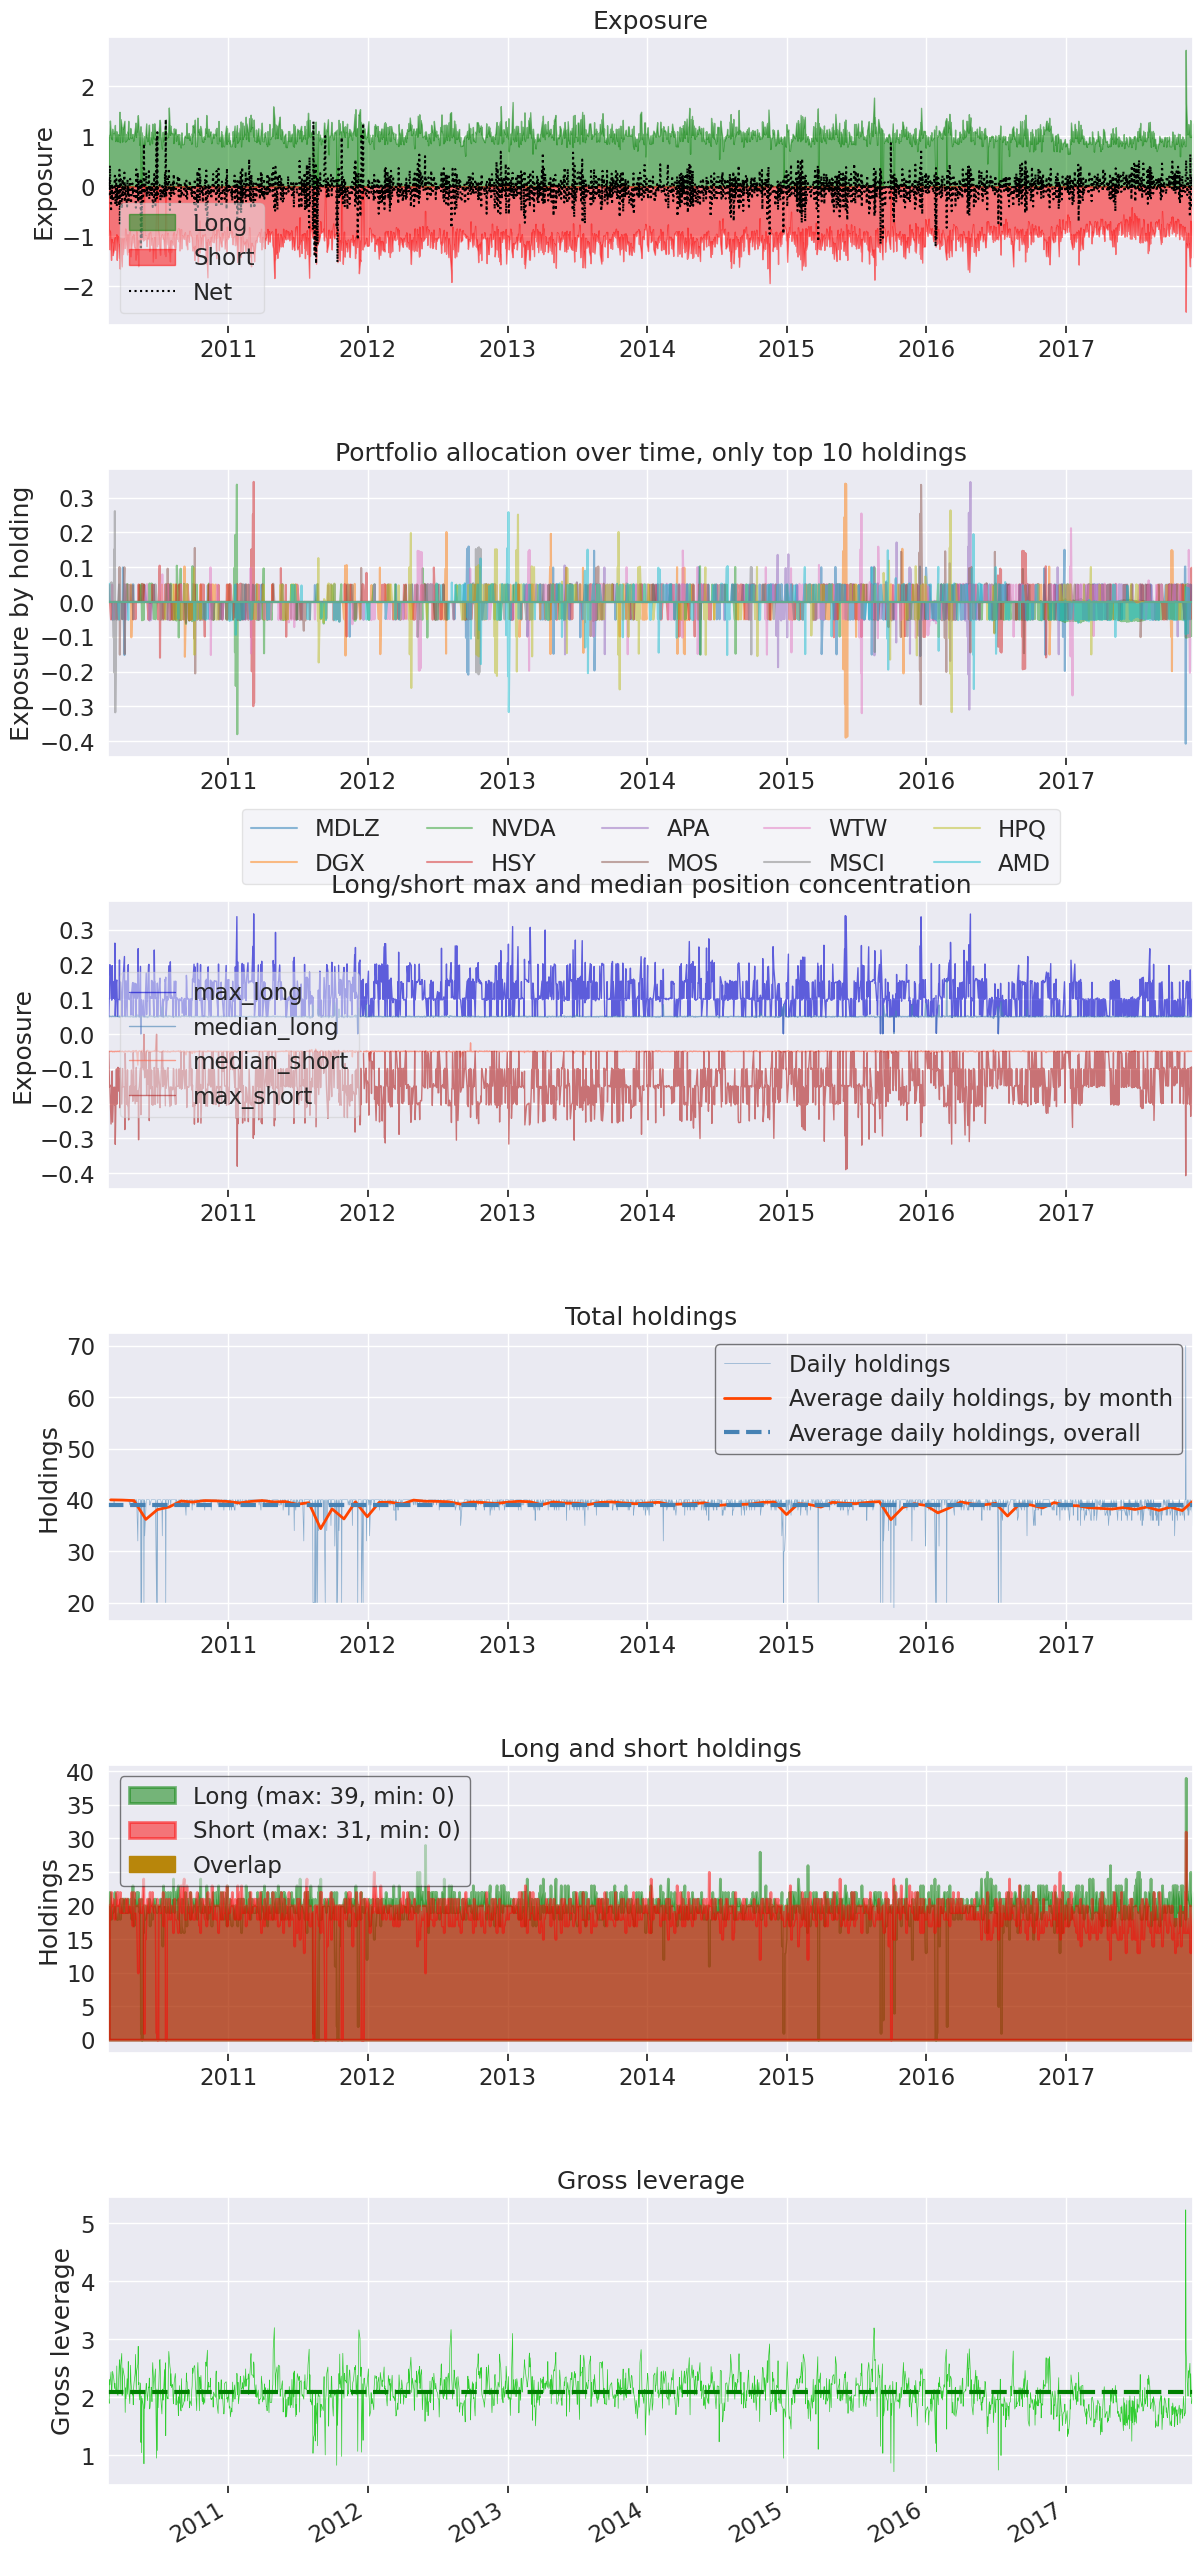

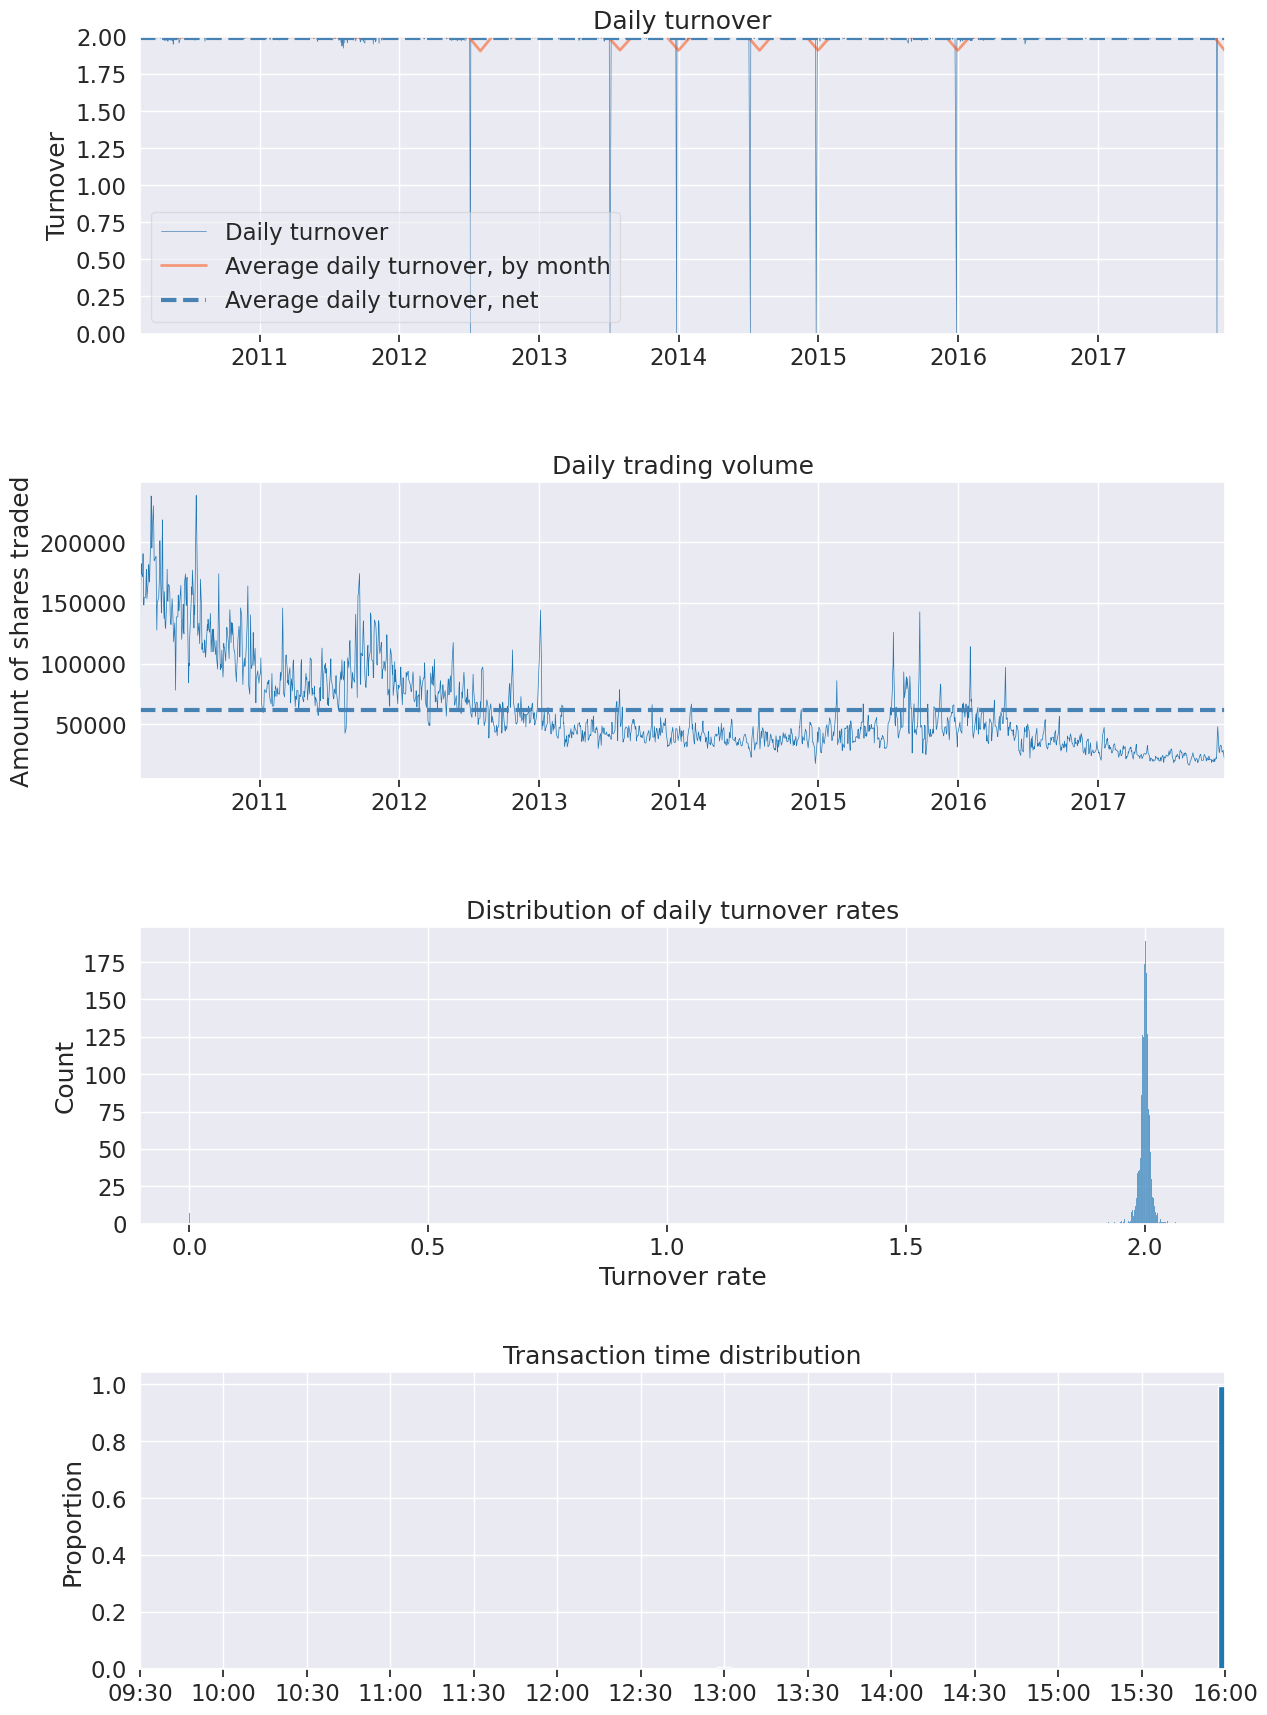

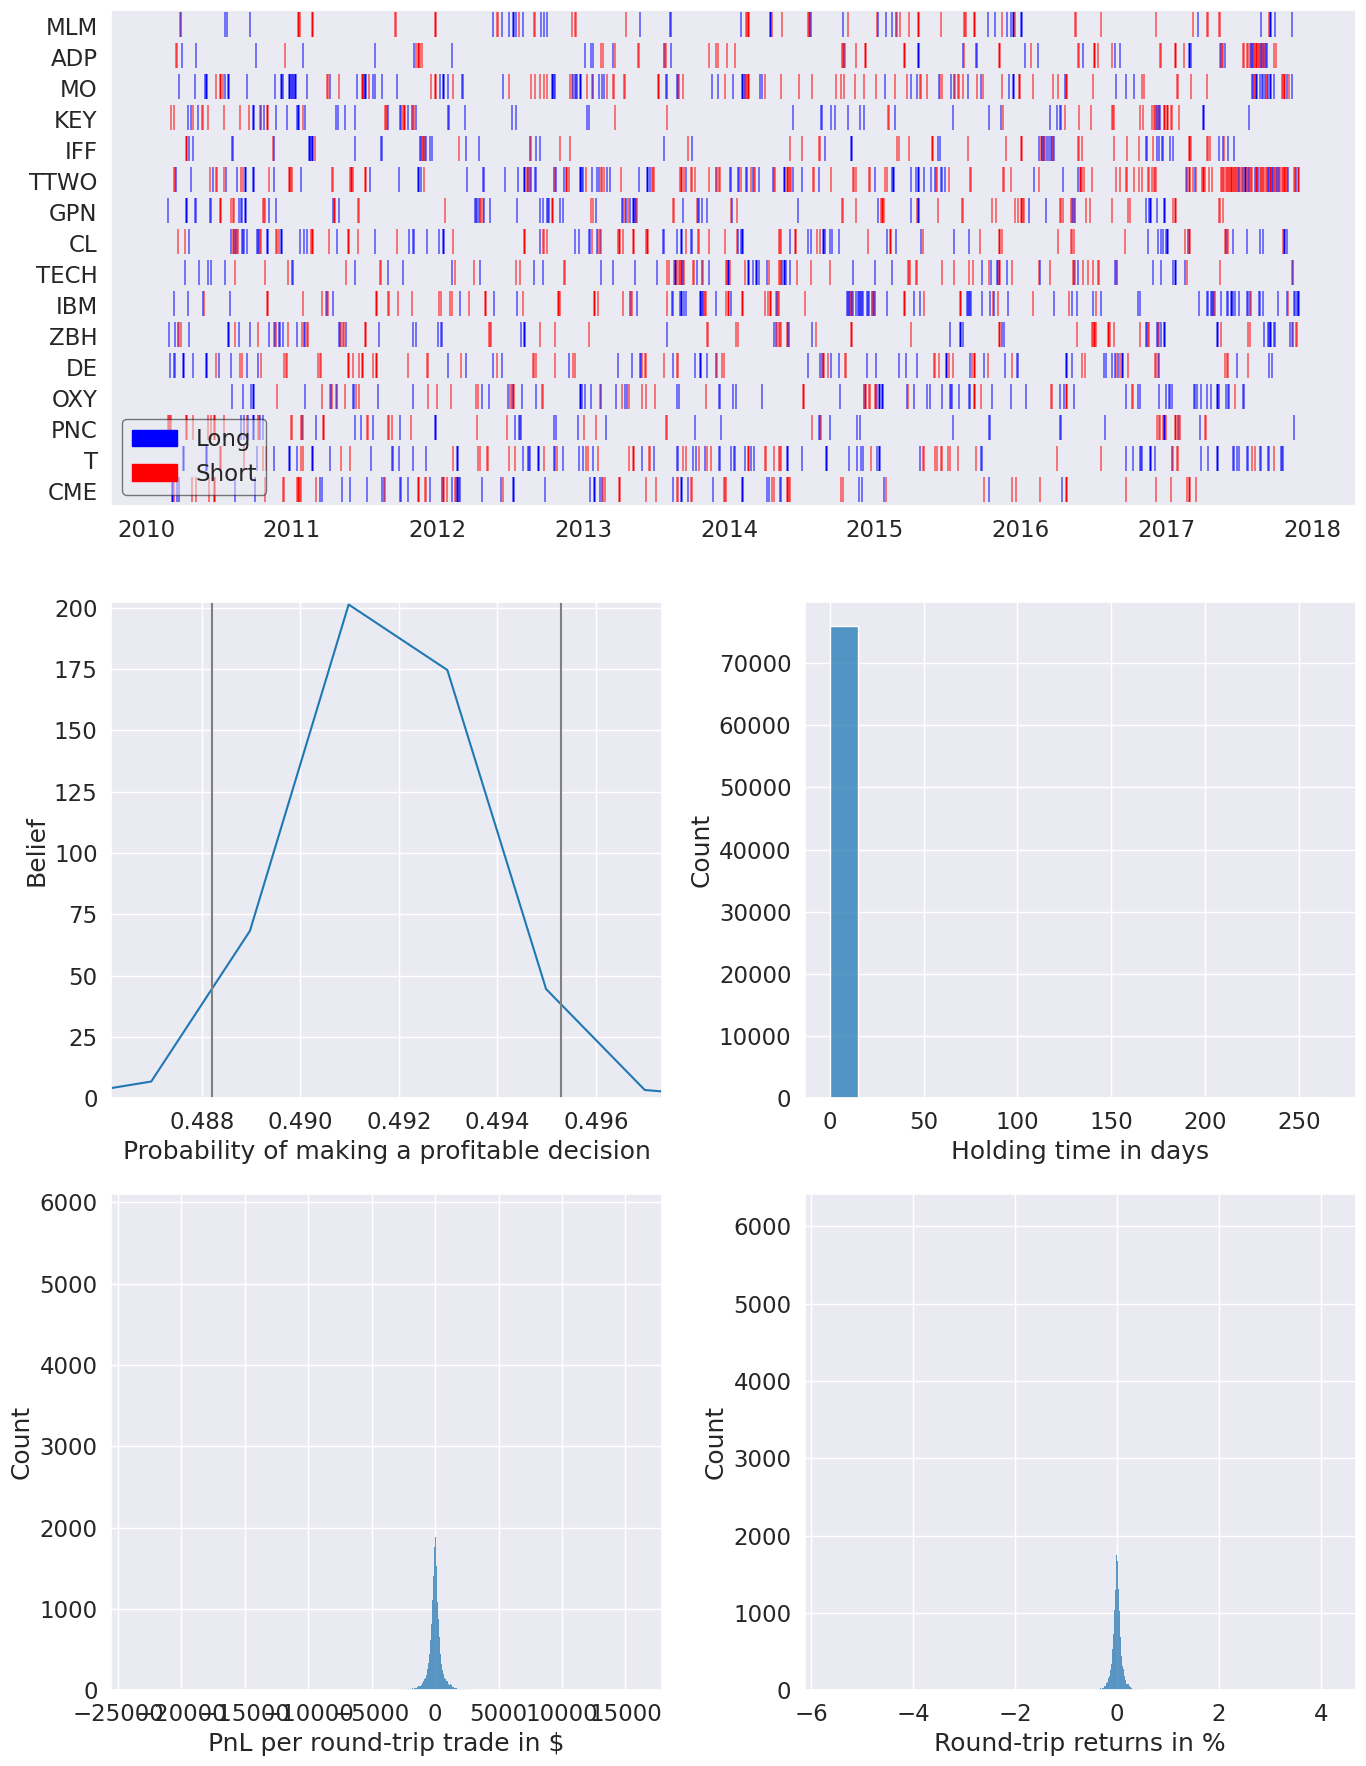

In [17]:
pf.create_full_tear_sheet(
    returns,
    transactions=transactions,
    positions=positions,
    live_start_date=LIVE_DATE,
    benchmark_rets=benchmark_data,
    round_trips=True
)

## Trading Strategy-II

### As seen in signal evaluations of the factors of the Ridge Model-14 (alpha=500), we will long factors in quantile-3 and short factors in quantile-5

In [18]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":3,
        "quantile_short":5
    }
}

In [19]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=5,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.00,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge14_factor",
    trading_strategy=trading_strategy
)

In [20]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

#### Extracting Information from Zipline Results

In [21]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

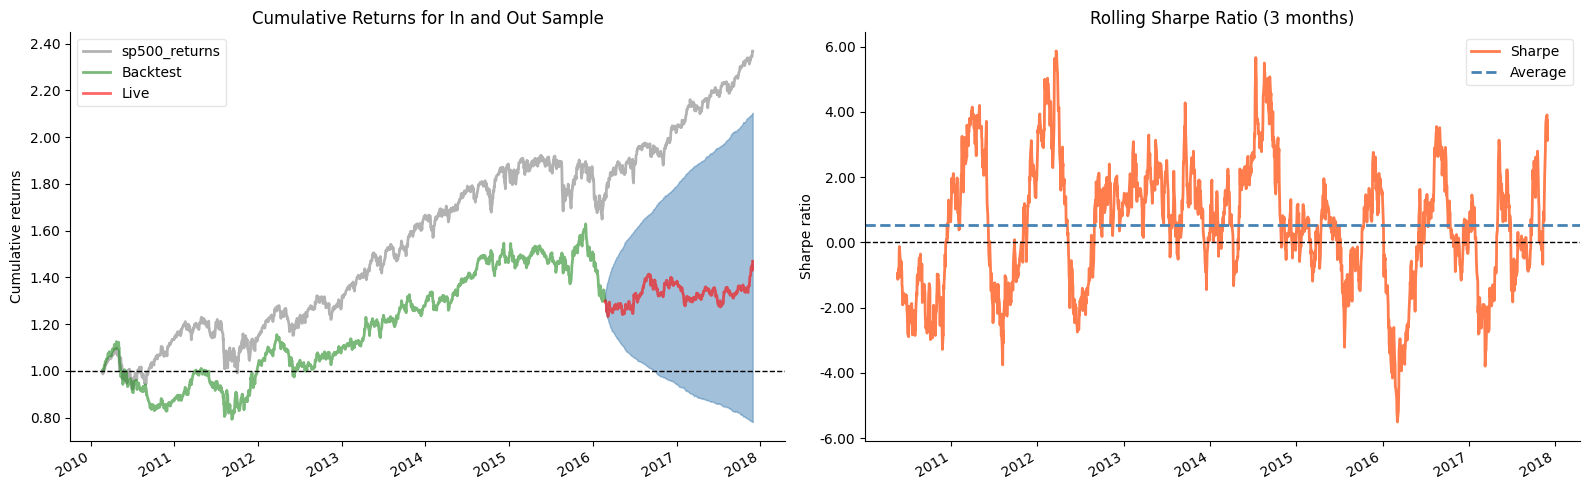

In [22]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,29.52,2010-04-23,2011-09-09,2012-03-19,497
1,24.32,2015-12-01,2016-03-08,NaT,NaN
2,15.68,2012-03-23,2012-06-07,2013-04-09,273
3,11.25,2014-12-09,2015-09-24,2015-11-02,235
4,7.17,2014-10-14,2014-10-30,2014-12-03,37


Stress Events,mean,min,max
US downgrade/European Debt Crisis,-0.11%,-6.47%,6.29%
Fukushima,0.20%,-1.14%,1.84%
EZB IR Event,0.05%,-1.45%,1.56%
Flash Crash,-1.79%,-3.48%,0.18%
Apr14,0.08%,-2.16%,0.94%
Oct14,-0.12%,-2.11%,2.11%
Fall2015,-0.13%,-4.21%,2.45%
Recovery,0.02%,-6.47%,6.29%
New Normal,0.03%,-4.21%,3.00%


Top 10 long positions of all time,max
sid,
ECL,21.45%
FE,20.40%
MAA,20.32%
JBL,19.95%
TRMB,19.88%
KMB,19.76%
TDY,19.74%
KLAC,19.22%
HAL,19.21%


Top 10 short positions of all time,max
sid,
BAX,-25.92%
FE,-25.48%
TDY,-24.74%
CPB,-23.66%
CRL,-22.31%
WTW,-20.35%
MDT,-20.20%
HPQ,-20.06%
BG,-19.95%


Top 10 positions of all time,max
sid,
BAX,25.92%
FE,25.48%
TDY,24.74%
CPB,23.66%
CRL,22.31%
ECL,21.45%
WTW,20.35%
MAA,20.32%
MDT,20.20%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$319653.64,$-600935.59,$920589.22
Gross profit,$17263937.45,$5485699.53,$11778237.92
Gross loss,$-16944283.82,$-6086635.12,$-10857648.69
Profit factor,$1.02,$0.90,$1.08
Avg. trade net profit,$6.69,$-40.19,$28.03
Avg. winning trade,$715.07,$768.84,$692.51
Avg. losing trade,$-728.82,$-791.71,$-697.75
Ratio Avg. Win:Avg. Loss,$0.98,$0.97,$0.99
Largest winning trade,$36934.69,$36934.69,$14891.52
Largest losing trade,$-37688.85,$-21152.34,$-37688.85


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 14:40:02.033203615,1 days 23:13:53.602167079,1 days 10:46:07.544314203
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,292 days 00:00:00,292 days 00:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,2.50%,2.50%,1.72%
Largest losing trade,-2.58%,-1.89%,-2.58%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.02%,0.01%,0.01%,0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,-0.01%,0.00%,0.00%,0.01%,0.00%,-0.02%,0.00%,-0.01%,-0.01%,0.02%,0.00%,0.00%,0.01%,-0.01%,-0.03%,-0.02%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,0.00%,-0.01%,0.02%,0.02%,0.01%,0.00%,-0.01%,-0.01%,-0.01%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,0.02%,0.01%,-0.01%,0.00%,0.01%,0.01%,-0.02%,0.01%,0.00%,-0.02%,0.01%,0.00%,-0.01%,0.01%,0.01%,0.00%,0.00%,0.02%,-0.00%,-0.02%,0.01%,0.01%,0.01%,0.01%,0.01%,0.01%,-0.02%,0.00%,0.00%,0.01%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,-0.02%,-0.01%,0.01%,0.00%,0.00%,0.00%,0.01%,0.02%,0.01%,0.00%,-0.00%,-0.01%,0.02%,-0.02%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.02%,0.00%,0.00%,-0.01%,-0.01%,-0.01%,0.01%,0.01%,0.00%,-0.00%,0.02%,-0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.02%,-0.01%,-0.00%,-0.01%,0.02%,0.01%,0.00%,0.00%,0.02%,0.01%,0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.01%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.02%,0.00%,-0.01%,0.01%,0.01%,0.01%,-0.00%,0.01%,-0.05%,0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.01%,-0.01%,0.01%,0.01%,0.01%,0.01%,0.00%,0.01%,0.01%,-0.00%,0.01%,0.00%,0.01%,-0.00%,0.01%,0.02%,0.01%,0.00%,0.01%,0.01%,0.01%,-0.00%,0.00%,-0.02%,-0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%,-0.01%,0.01%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.02%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,0.02%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.01%,0.03%,0.00%,0.01%,-0.01%,0.01%,-0.01%,-0.00%,-0.02%,-0.01%,-0.00%,0.01%,-0.01%,-0.00%,-0.01%,0.00%,0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.01%,0.01%,0.02%,-0.01%,-0.01%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.01%,-0.01%,-0.01%,-0.00%,-0.01%,-0.01%,-0.00%,-0.02%,-0.00%,0.01%,-0.00%,-0.00%,0.00%,0.01%,0.01%,0.02%,0.01%,0.00%,0.00%,-0.00%,-0.02%,0.01%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.01%,-0.01%,0.01%,0.01%,0.01%,0.00%,0.01%,0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.02%,-0.02%,-0.00%,-0.02%,0.01%,0.01%,0.01%,0.01%,0.01%,-0.01%,0.01%,0.01%,0.02%,0.00%,0.01%,-0.01%,0.03%,0.01%,0.01%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.03%,0.01%,0.00%,0.01%,-0.00%,0.01%,0.00%,0.01%
Avg returns winning,0.05%,0.03%

Profitability (PnL / PnL total) per name,
symbol,
WTW,15.91%
URI,14.76%
DXCM,14.25%
HPQ,13.12%
CPB,12.13%
FFIV,11.34%
NDSN,11.32%
TTWO,10.34%
MGM,10.20%


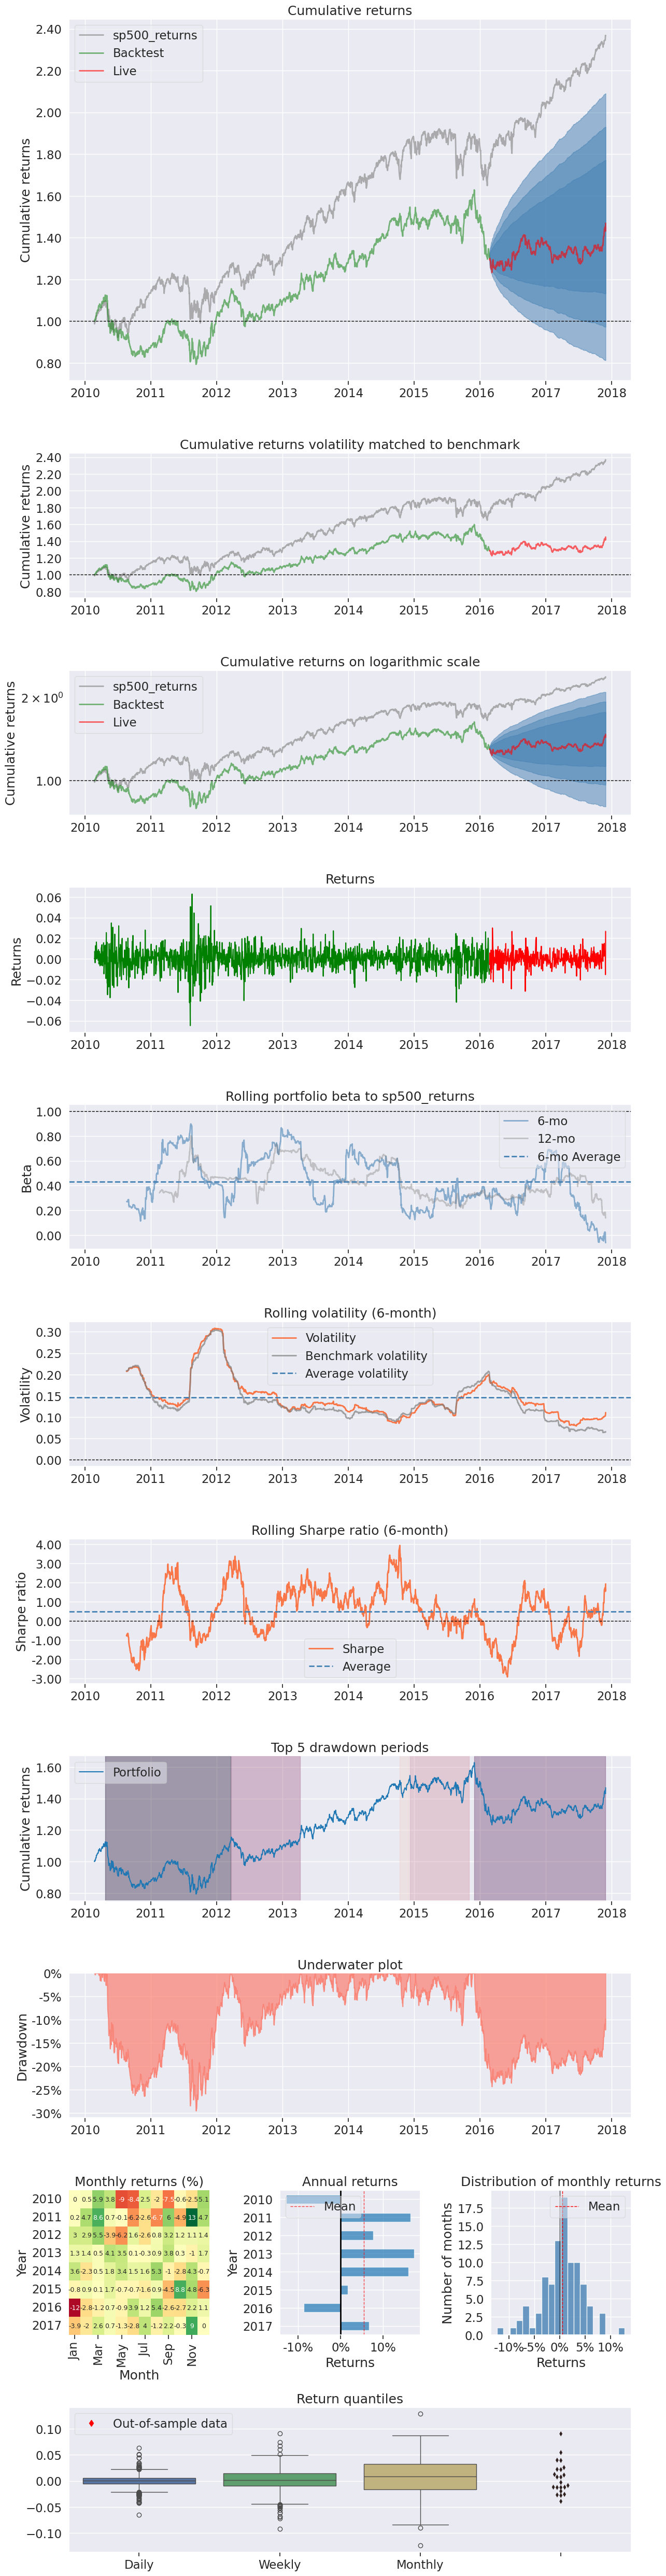

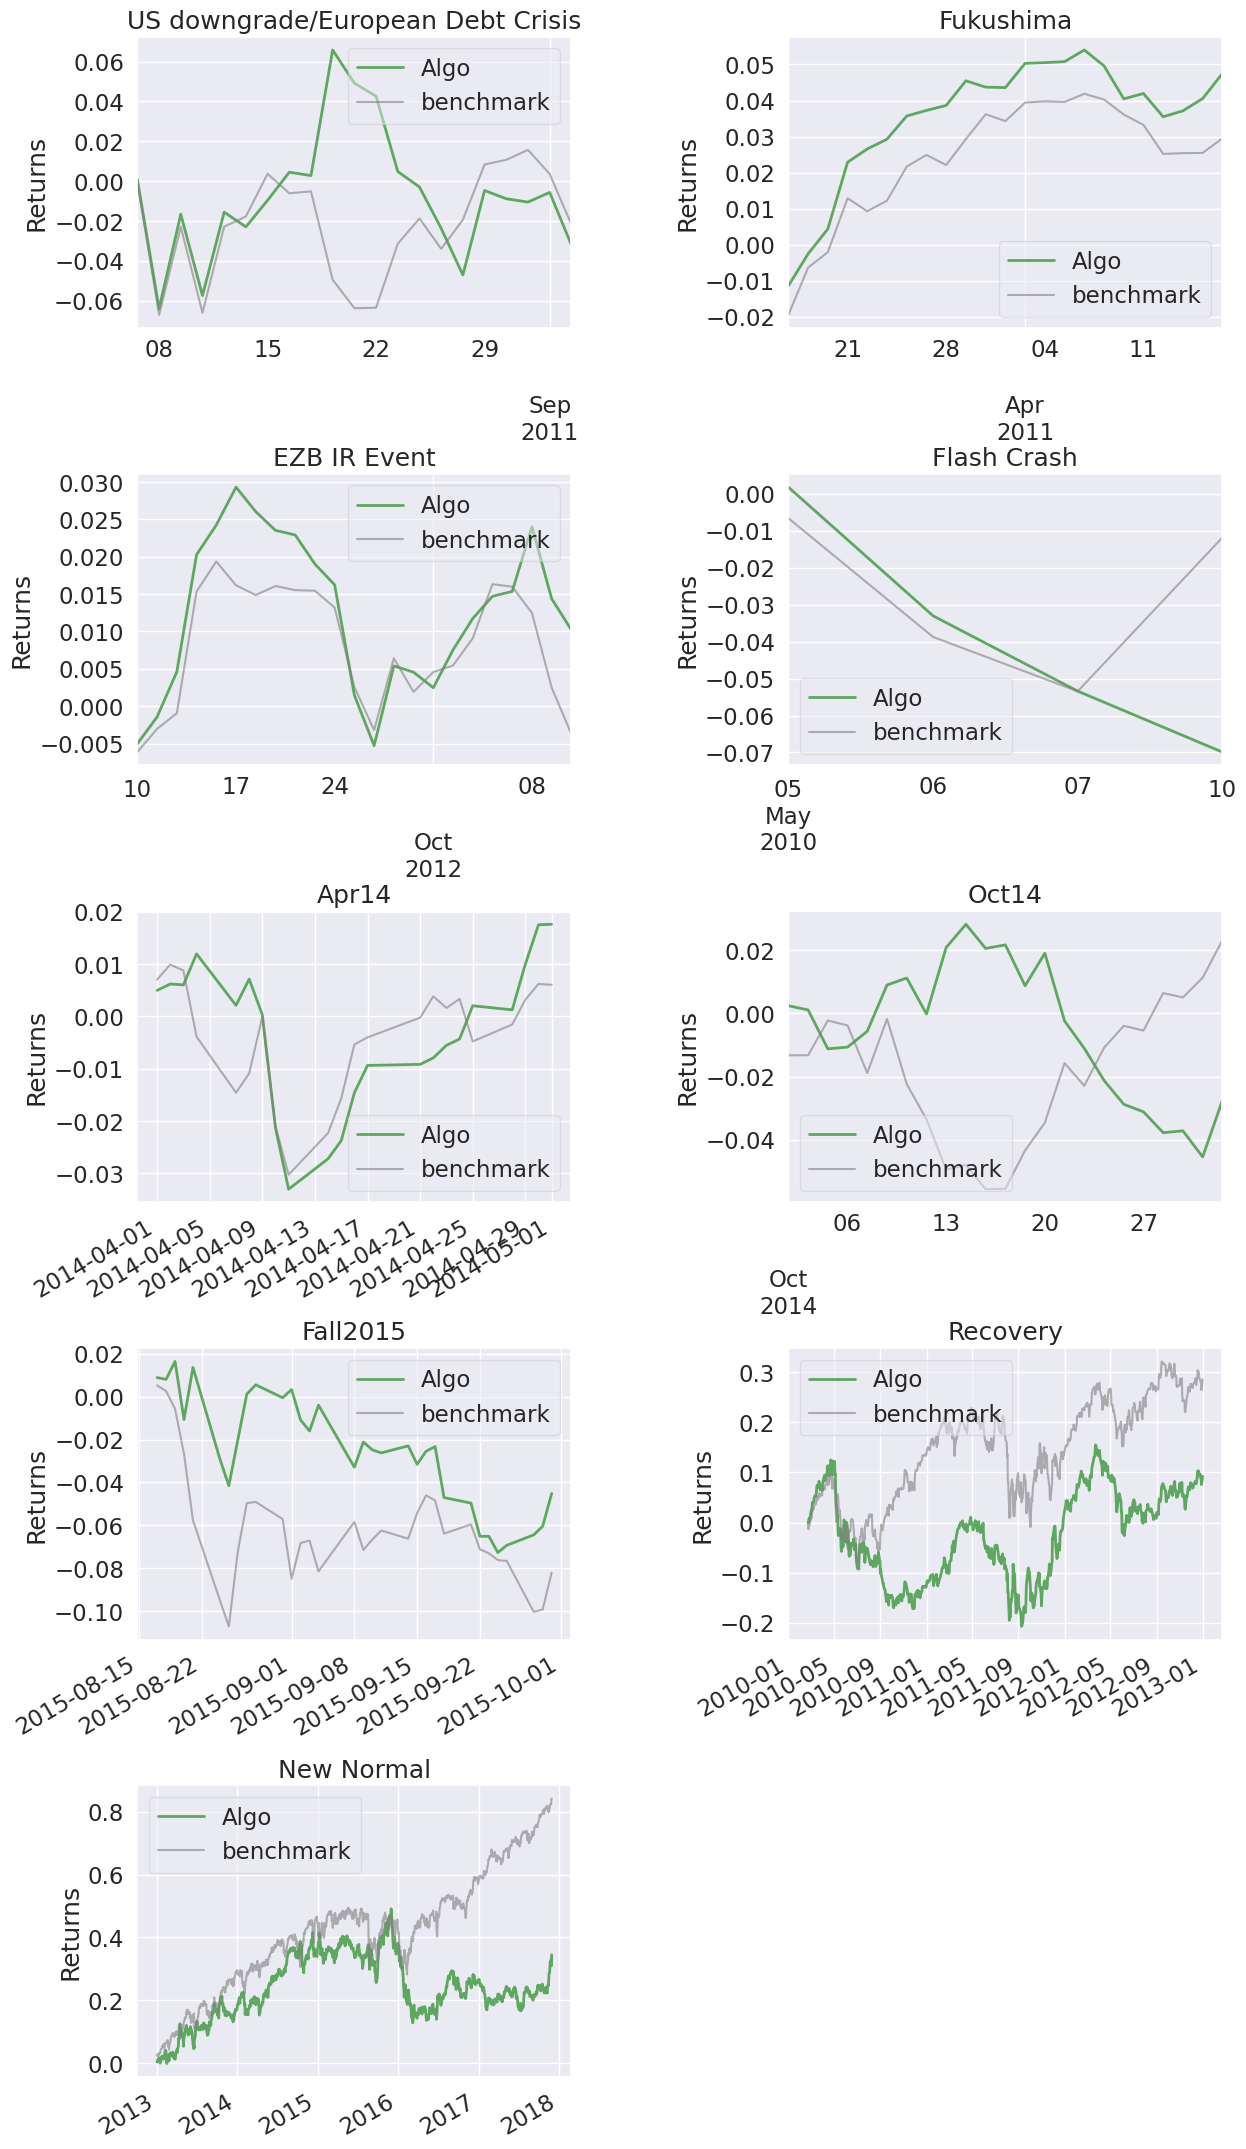

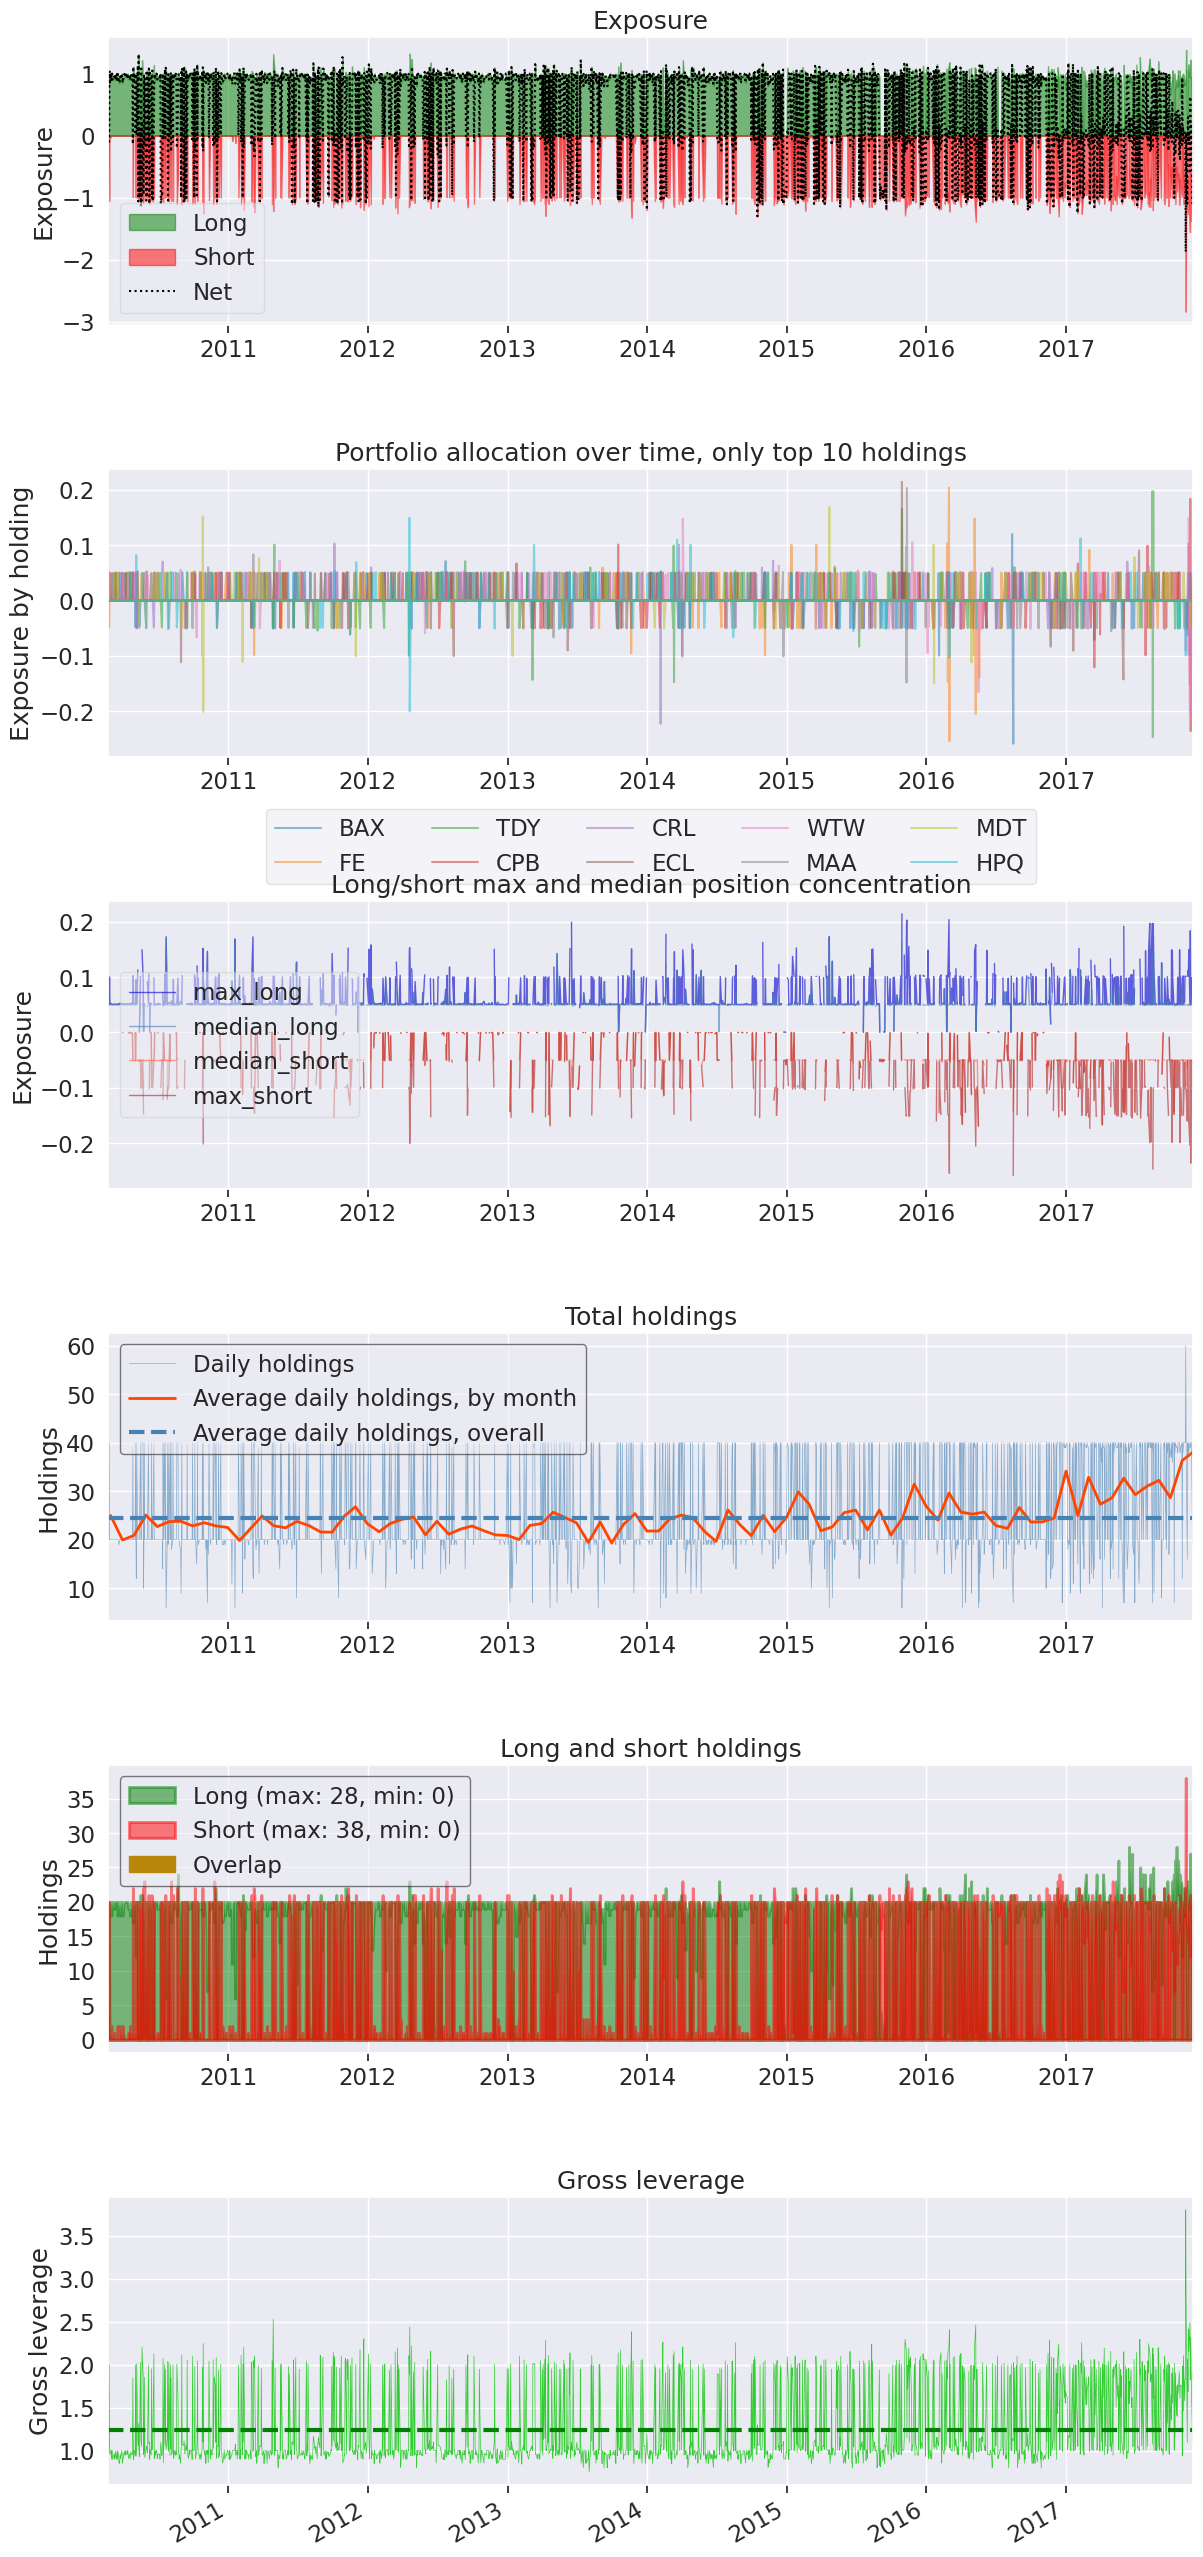

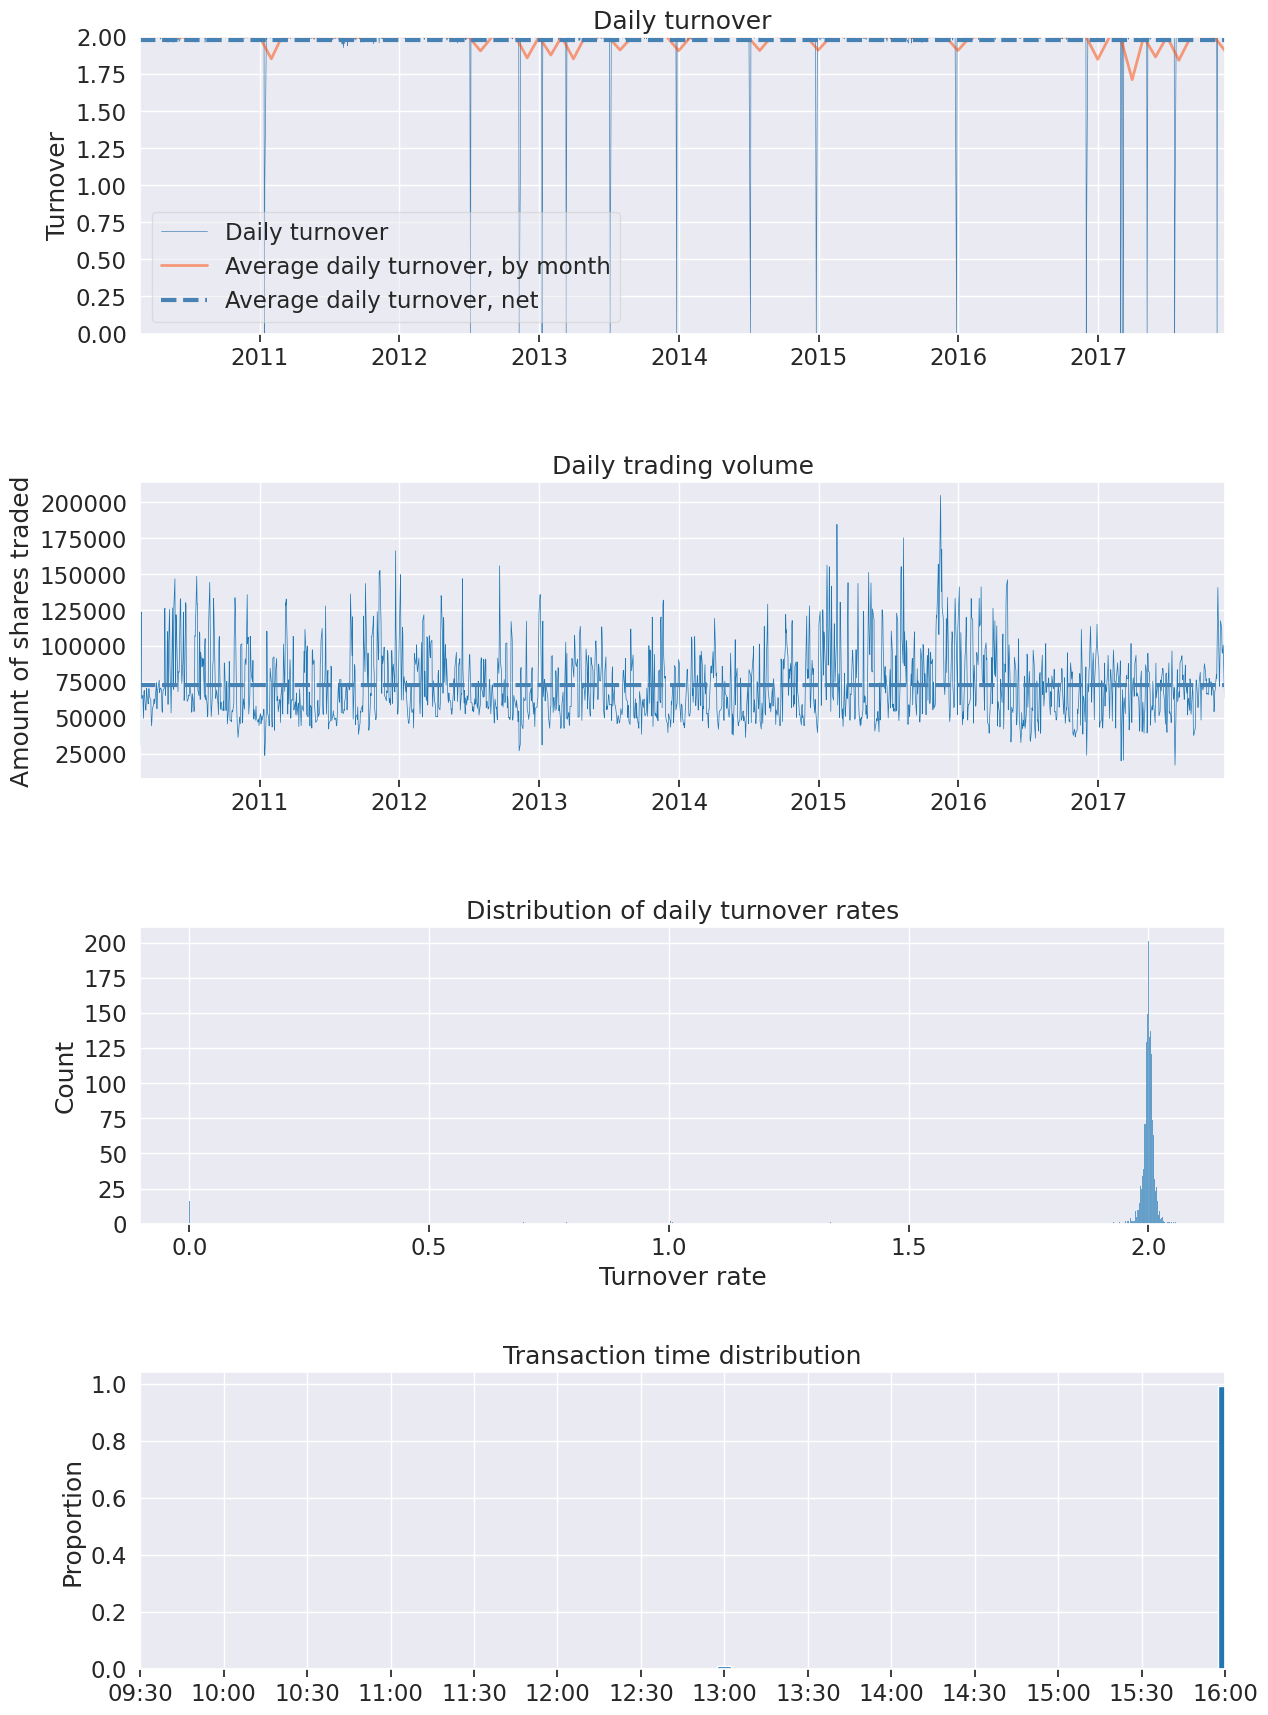

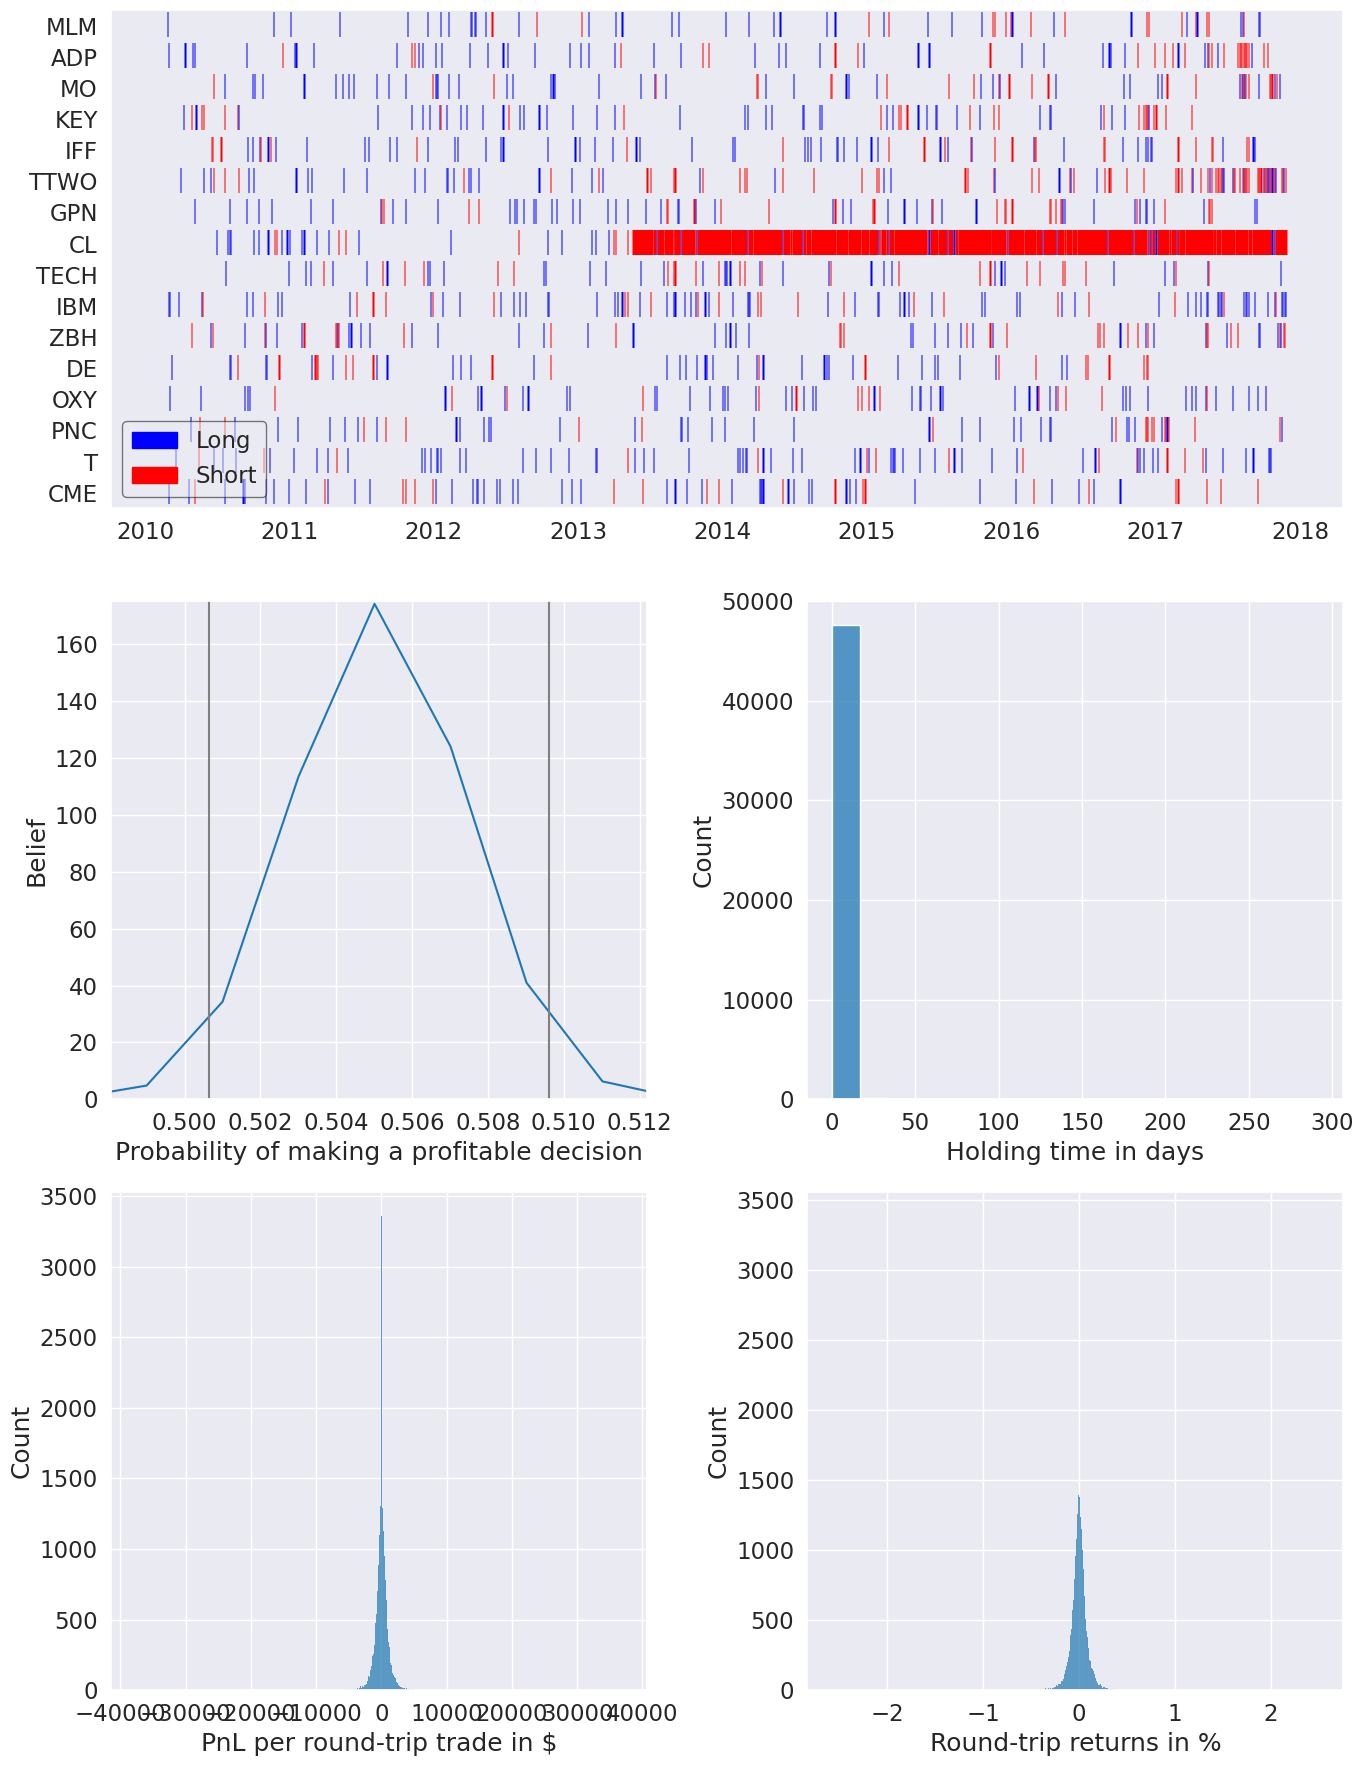

In [23]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)